# Stage 1: Data Lake Foundation

Setting up the HDFS data lake for MediaWave Streaming. This notebook creates the directory structure, loads the raw datasets into the landing zone, sets replication factors, and documents the architecture decisions.

## MediaWave Streaming

MediaWave is a streaming platform with 200,000 users and a catalog of 20,000 titles. The company wants to understand what content keeps viewers engaged, identify users likely to churn, and figure out how streaming quality affects the viewing experience.

## Data Sources

We have 5 datasets:
- **viewing-histor-.csv.gz** — 700K records of what us,rs watched, how long, and whether they finished
- **content-catalo-.json.gz** — 20K titles with genres, ratings, IMDB scores, and license costs
- **user-profi-es.csv.gz** — 200K user accounts with plan type, country, watch hours, and churn status
- **user-interacti-ns.json.gz** — 550K user actions like browsing, searching, rating, and sharing
- **streaming-quality.csv.gz** — 200K session logs with buffering events, bitrate, and latency

## HDFS Zone Design

The data lake has three zones:

**Landing zone** — Raw data exactly as received. No cleaning, no changes. CSV and JSON files stay in their original format. This is our audit trail — we can always go back to the original data.

**Curated zone** — Cleaned and standardized data. Nulls handled, types fixed, duplicates removed. Stored as Parquet for fast columnar reads.

**Analytics zone** — Aggregated tables that answer specific business questions. Also Parquet, partitioned by the fields analysts will filter on. Ready for dashboards and reports.d reports.

## Connect to HDFS

Since this notebook runs inside the Jupyter container, we connect to HDFS using its WebHDFS REST API. The namenode is reachable at http://namenode:9870 because all containers share the same Docker network.

In [ ]:
import requests

HDFS_URL = "http://namenode:9870/webhdfs/v1"

def hdfs_mkdir(path):
    """Create a directory in HDFS."""
    r = requests.put(f"{HDFS_URL}{path}?op=MKDIRS&user.name=root")
    return r.json()

def hdfs_put(local_path, hdfs_path):
    """Upload a file to HDFS."""
    r = requests.put(
        f"{HDFS_URL}{hdfs_path}?op=CREATE&user.name=root&overwrite=true",
        allow_redirects=False
    )
    redirect_url = r.headers['Location']
    with open(local_path, 'rb') as f:
        requests.put(redirect_url, data=f)

def hdfs_ls(path):
    """List contents of an HDFS directory."""
    r = requests.get(f"{HDFS_URL}{path}?op=LISTSTATUS&user.name=root")
    data = r.json()
    if 'FileStatuses' in data:
        for item in data['FileStatuses']['FileStatus']:
            kind = "d" if item['type'] == 'DIRECTORY' else "-"
            size = item['length']
            name = item['pathSuffix']
            print(f"  {kind}  {size:>12}  {name}")

# Test connection
r = requests.get(f"{HDFS_URL}/?op=LISTSTATUS&user.name=root")
print("Connected to HDFS." if r.status_code == 200 else "ERROR: Cannot reach HDFS.")

Connected to HDFS.


## Create Landing Zone Directories

One subfolder per data source. Each file gets its own directory so we can set different replication factors and keep things organized.

In [ ]:
# Landing zone - raw data as-is
hdfs_mkdir("/mediawave-lake/landing/viewing-history")
hdfs_mkdir("/mediawave-lake/landing/content-catalog")
hdfs_mkdir("/mediawave-lake/landing/user-profiles")
hdfs_mkdir("/mediawave-lake/landing/user-interactions")
hdfs_mkdir("/mediawave-lake/landing/streaming-quality")

# Curated zone - Stage 2 will write cleaned Parquet here
hdfs_mkdir("/mediawave-lake/curated/viewing-history")
hdfs_mkdir("/mediawave-lake/curated/content-catalog")
hdfs_mkdir("/mediawave-lake/curated/user-profiles")
hdfs_mkdir("/mediawave-lake/curated/user-interactions")
hdfs_mkdir("/mediawave-lake/curated/streaming-quality")

# Analytics zone - aggregated tables for business questions
hdfs_mkdir("/mediawave-lake/analytics/content-performance")
hdfs_mkdir("/mediawave-lake/analytics/viewer-engagement")
hdfs_mkdir("/mediawave-lake/analytics/churn-analysis")
hdfs_mkdir("/mediawave-lake/analytics/quality-impact")

print("All directories created.")

All directories created.


In [ ]:
# Verify the directory structure
print("=== Landing Zone ===")
hdfs_ls("/mediawave-lake/landing")
print("\n=== Curated Zone ===")
hdfs_ls("/mediawave-lake/curated")
print("\n=== Analytics Zone ===")
hdfs_ls("/mediawave-lake/analytics")

=== Landing Zone ===
  d             0  content-catalog
  d             0  streaming-quality
  d             0  user-interactions
  d             0  user-profiles
  d             0  viewing-history

=== Curated Zone ===
  d             0  content-catalog
  d             0  streaming-quality
  d             0  user-interactions
  d             0  user-profiles
  d             0  viewing-history

=== Analytics Zone ===
  d             0  churn-analysis
  d             0  content-performance
  d             0  quality-impact
  d             0  viewer-engagement


## Load Raw Data into Landing Zone

Uploading the 5 compressed data files into their landing zone directories. The files stay in their original format (CSV and JSON).

In [ ]:
import os

data_dir = "/home/jovyan/data"

files = {
    "viewing-history.csv.gz": "/mediawave-lake/landing/viewing-history/viewing-history.csv.gz",
    "content-catalog.json.gz": "/mediawave-lake/landing/content-catalog/content-catalog.json.gz",
    "user-profiles.csv.gz": "/mediawave-lake/landing/user-profiles/user-profiles.csv.gz",
    "user-interactions.json.gz": "/mediawave-lake/landing/user-interactions/user-interactions.json.gz",
    "streaming-quality.csv.gz": "/mediawave-lake/landing/streaming-quality/streaming-quality.csv.gz",
}

for filename, hdfs_path in files.items():
    local_path = os.path.join(data_dir, filename)
    size_mb = os.path.getsize(local_path) / (1024 * 1024)
    print(f"Uploading {filename} ({size_mb:.1f} MB)...")
    hdfs_put(local_path, hdfs_path)
    print(f"  Done.")

print("\nAll files uploaded to landing zone.")

Uploading viewing-history.csv.gz (15.4 MB)...
  Done.
Uploading content-catalog.json.gz (0.5 MB)...
  Done.
Uploading user-profiles.csv.gz (2.3 MB)...
  Done.
Uploading user-interactions.json.gz (8.9 MB)...
  Done.
Uploading streaming-quality.csv.gz (3.5 MB)...
  Done.

All files uploaded to landing zone.


In [ ]:
# Verify all files landed correctly
print("=== Files in Landing Zone ===\n")
for folder in ["viewing-history", "content-catalog", "user-profiles", "user-interactions", "streaming-quality"]:
    print(f"{folder}/")
    hdfs_ls(f"/mediawave-lake/landing/{folder}")
    print()

=== Files in Landing Zone ===

viewing-history/
  -      16180018  viewing-history.csv.gz

content-catalog/
  -        533164  content-catalog.json.gz

user-profiles/
  -       2419112  user-profiles.csv.gz

user-interactions/
  -       9365393  user-interactions.json.gz

streaming-quality/
  -       3641961  streaming-quality.csv.gz



## Replication Strategy

HDFS replicates data across datanodes for fault tolerance. The default in our cluster is RF=2 (set in docker-compose.yml). We adjust per directory based on two things: how critical the data is and how large it is.


In [ ]:
def hdfs_setrep(replication, path):
    """Set replication factor for an HDFS path."""
    r = requests.put(
        f"{HDFS_URL}{path}?op=SETREPLICATION&replication={replication}&user.name=root"
    )
    return r.json()

# High-volume, reloadable data - RF=1 to save storage
hdfs_setrep(1, "/mediawave-lake/landing/viewing-history/viewing-history.csv.gz")
hdfs_setrep(1, "/mediawave-lake/landing/user-interactions/user-interactions.json.gz")

# Critical reference data and quality metrics - keep RF=2
hdfs_setrep(2, "/mediawave-lake/landing/content-catalog/content-catalog.json.gz")
hdfs_setrep(2, "/mediawave-lake/landing/user-profiles/user-profiles.csv.gz")
hdfs_setrep(2, "/mediawave-lake/landing/streaming-quality/streaming-quality.csv.gz")

print("Replication factors set.")

Replication factors set.


## File Format Choices
Landing zone**

The raw files stay in their original formats. viewing-history, user-profiles, and streaming-quality arrived as CSV. content-catalog and user-interactions arrived as JSON. Changing the format at ingest would mean we no longer have the original data, which defeats the purpose of the landing zone. If something goes wrong in a transform, we can always come back he analytics workload.

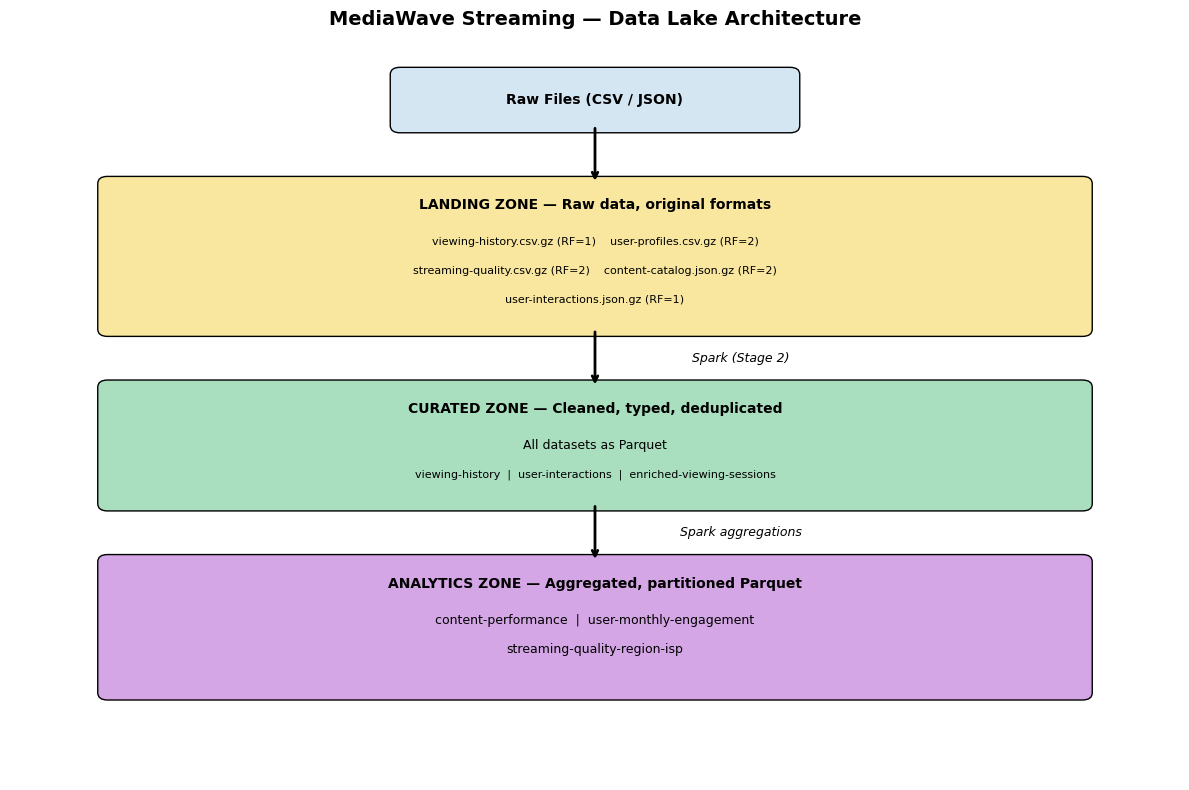

Diagram saved.


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.set_xlim(0, 12)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title("MediaWave Streaming — Data Lake Architecture", fontsize=14, fontweight='bold', pad=20)

# Raw files box
ax.add_patch(patches.FancyBboxPatch((4, 9), 4, 0.7, boxstyle="round,pad=0.1", facecolor="#d4e6f1", edgecolor="black"))
ax.text(6, 9.35, "Raw Files (CSV / JSON)", ha='center', va='center', fontsize=10, fontweight='bold')

# Arrow
ax.annotate('', xy=(6, 8.2), xytext=(6, 9), arrowprops=dict(arrowstyle='->', color='black', lw=2))

# Landing zone
ax.add_patch(patches.FancyBboxPatch((1, 6.2), 10, 2, boxstyle="round,pad=0.1", facecolor="#f9e79f", edgecolor="black"))
ax.text(6, 7.9, "LANDING ZONE — Raw data, original formats", ha='center', va='center', fontsize=10, fontweight='bold')
ax.text(6, 7.4, "viewing-history.csv.gz (RF=1)    user-profiles.csv.gz (RF=2)", ha='center', va='center', fontsize=8)
ax.text(6, 7.0, "streaming-quality.csv.gz (RF=2)    content-catalog.json.gz (RF=2)", ha='center', va='center', fontsize=8)
ax.text(6, 6.6, "user-interactions.json.gz (RF=1)", ha='center', va='center', fontsize=8)

# Arrow
ax.annotate('', xy=(6, 5.4), xytext=(6, 6.2), arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.text(7.5, 5.8, "Spark (Stage 2)", ha='center', va='center', fontsize=9, fontstyle='italic')

# Curated zone
ax.add_patch(patches.FancyBboxPatch((1, 3.8), 10, 1.6, boxstyle="round,pad=0.1", facecolor="#a9dfbf", edgecolor="black"))
ax.text(6, 5.1, "CURATED ZONE — Cleaned, typed, deduplicated", ha='center', va='center', fontsize=10, fontweight='bold')
ax.text(6, 4.6, "All datasets as Parquet", ha='center', va='center', fontsize=9)
ax.text(6, 4.2, "viewing-history  |  user-interactions  |  enriched-viewing-sessions", ha='center', va='center', fontsize=8)

# Arrow
ax.annotate('', xy=(6, 3.0), xytext=(6, 3.8), arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.text(7.5, 3.4, "Spark aggregations", ha='center', va='center', fontsize=9, fontstyle='italic')

# Analytics zone
ax.add_patch(patches.FancyBboxPatch((1, 1.2), 10, 1.8, boxstyle="round,pad=0.1", facecolor="#d5a6e6", edgecolor="black"))
ax.text(6, 2.7, "ANALYTICS ZONE — Aggregated, partitioned Parquet", ha='center', va='center', fontsize=10, fontweight='bold')
ax.text(6, 2.2, "content-performance  |  user-monthly-engagement", ha='center', va='center', fontsize=9)
ax.text(6, 1.8, "streaming-quality-region-isp", ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.savefig("/home/jovyan/notebooks/architecture-diagram.png", dpi=150, bbox_inches='tight')
plt.show()
print("Diagram saved.")

## Summary

Stage 1 is complete. Here is what was done:

1. Created three-zone HDFS structure: landing, curated, and analytics
2. Loaded all 5 MediaWave datasets into the landing zone
3. Set replication factors based on data criticality (RF=2 for critical reference data, RF=1 for large reloadable datasets)
4. Documented file format choices and architecture design

The landing zone is ready for Stage 2 to begin Spark transforms. Data is at hdfs://namenode:9000/mediawave-lake/landing/